In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

def read_tsp_data(file_path):
    city_coordinates = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        in_node_coord_section = False
        for line in lines:
            line = line.strip()
            if line == 'EOF':
                break
            if line == 'NODE_COORD_SECTION':
                in_node_coord_section = True
                continue
            if in_node_coord_section:
                parts = line.split()
                city_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                city_coordinates[city_id] = (x, y)
    return city_coordinates

file_path = '/kaggle/input/att48-tsp/att48.tsp'
city_coordinates = read_tsp_data(file_path)
x_coords = [coord[0] for coord in city_coordinates.values()]
y_coords = [coord[1] for coord in city_coordinates.values()]
plt.scatter(x_coords, y_coords)
plt.title('att48.tsp City Coordinates Distribution')
plt.xlabel('X Coordinate (COORD)')
plt.ylabel('Y Coordinate (SECTION)')
plt.show()

file_path = '/kaggle/input/st70-tsp/st70.tsp'
city_coordinates = read_tsp_data(file_path)
x_coords = [coord[0] for coord in city_coordinates.values()]
y_coords = [coord[1] for coord in city_coordinates.values()]
plt.scatter(x_coords, y_coords)
plt.title('st70.tsp City Coordinates Distribution')
plt.xlabel('X Coordinate (COORD)')
plt.ylabel('Y Coordinate (SECTION)')
plt.show()

file_path = '/kaggle/input/pr124-tsp/pr124.tsp'
city_coordinates = read_tsp_data(file_path)
x_coords = [coord[0] for coord in city_coordinates.values()]
y_coords = [coord[1] for coord in city_coordinates.values()]
plt.scatter(x_coords, y_coords)
plt.title('pr124.tsp City Coordinates Distribution')
plt.xlabel('X Coordinate (COORD)')
plt.ylabel('Y Coordinate (SECTION)')
plt.show()

file_path = '/kaggle/input/att532-tsp/att532.tsp'
city_coordinates = read_tsp_data(file_path)
x_coords = [coord[0] for coord in city_coordinates.values()]
y_coords = [coord[1] for coord in city_coordinates.values()]
plt.scatter(x_coords, y_coords)
plt.title('att532.tsp City Coordinates Distribution')
plt.xlabel('X Coordinate (COORD)')
plt.ylabel('Y Coordinate (SECTION)')
plt.show()

遗传算法

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time

def read_tsp_data(file_path):
    city_coordinates = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        in_node_coord_section = False
        for line in lines:
            line = line.strip()
            if line == 'EOF':
                break
            if line == 'NODE_COORD_SECTION':
                in_node_coord_section = True
                continue
            if in_node_coord_section:
                parts = line.split()
                city_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                city_coordinates[city_id] = (x, y)
    return city_coordinates

def calculate_distance_matrix(city_coordinates):
    num_cities = len(city_coordinates)
    distance_matrix = np.zeros((num_cities, num_cities))
    sorted_cities = sorted(city_coordinates.keys())
    for i in range(num_cities):
        for j in range(num_cities):
            if i == j:
                distance_matrix[i][j] = np.inf
                continue
            city1 = sorted_cities[i]
            city2 = sorted_cities[j]
            x1, y1 = city_coordinates[city1]
            x2, y2 = city_coordinates[city2]
            distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
            distance_matrix[i][j] = distance
    return distance_matrix

def path_length(path, distances):
    length = 0
    num_cities = len(path)
    for i in range(num_cities - 1):
        length += distances[path[i], path[i + 1]]
    length += distances[path[-1], path[0]]
    return length

def generate_population(num_cities, population_size):
    population = []
    for _ in range(population_size):
        path = list(range(num_cities))
        random.shuffle(path)
        population.append(path)
    return population

def fitness(path, distances):
    return 1 / path_length(path, distances)

def tournament_selection(population, distances, tournament_size=3):
    selected = []
    for _ in range(len(population)):
        candidates = random.sample(population, tournament_size)
        winner = min(candidates, key=lambda x: path_length(x, distances))
        selected.append(winner)
    return selected

def pmx_crossover(parent1, parent2):
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [-1] * size
    child[start:end] = parent1[start:end]
    for i in range(start, end):
        if parent2[i] not in child:
            j = i
            while child[j] != -1:
                j = parent2.index(parent1[j])
            child[j] = parent2[i]
    for i in range(size):
        if child[i] == -1:
            child[i] = parent2[i]
    return child

def inversion_mutation(path):
    start, end = sorted(random.sample(range(len(path)), 2))
    path[start:end] = path[start:end][::-1]
    return path

def two_opt(path, distances):
    improved = True
    while improved:
        improved = False
        for i in range(1, len(path) - 2):
            for j in range(i + 1, len(path)):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                if path_length(new_path, distances) < path_length(path, distances):
                    path = new_path
                    improved = True
    return path

def dynamic_mutation_rate(generation, max_generations):
    initial_rate = 0.2
    final_rate = 0.05
    return initial_rate - (initial_rate - final_rate) * (generation / max_generations)

def genetic_algorithm_optimized(num_cities, population_size, generations, distances, n_generation_output):
    population = generate_population(num_cities, population_size)
    best_paths = []
    best_lengths = []
    start_time = time.time()
    shortest_length = np.inf
    for generation in range(generations):
        mutation_rate = dynamic_mutation_rate(generation, generations)
        selected_population = tournament_selection(population, distances)
        new_population = []
        while len(new_population) < population_size:
            parent1, parent2 = random.sample(selected_population, 2)
            child = pmx_crossover(parent1, parent2)
            if random.random() < mutation_rate:
                child = inversion_mutation(child)
            new_population.append(child)
        for i in range(len(new_population)):
            if random.random() < 0.1:
                new_population[i] = two_opt(new_population[i], distances)
        population = new_population
        best_path = min(population, key=lambda x: path_length(x, distances))
        best_paths.append(best_path)
        best_lengths.append(path_length(best_path, distances))
        if path_length(best_path, distances) < shortest_length:
            shortest_length = path_length(best_path, distances) 
            earliest_shortest_path_generation = generation
        if (generation + 1) % n_generation_output == 0: 
            print(f"generation:{generation + 1}  best_lengths:{best_lengths[generation]}  time:{time.time() - start_time}")
    final_best_path = min(best_paths, key=lambda x: path_length(x, distances))
    final_best_length = path_length(final_best_path, distances)
    end_time = time.time()
    return final_best_path, final_best_length, best_lengths, end_time - start_time, earliest_shortest_path_generation 

generation:10  best_lengths:34400.25719461214  time:23.716891288757324
generation:20  best_lengths:34144.9502391175  time:49.022465229034424
generation:30  best_lengths:34155.57183451457  time:75.60136938095093
generation:40  best_lengths:34198.455332841935  time:102.3802535533905
generation:50  best_lengths:34692.961862450844  time:127.97035241127014
generation:60  best_lengths:34281.2421586666  time:147.58296966552734
generation:70  best_lengths:33766.69346108101  time:163.05916261672974
generation:80  best_lengths:33588.34340921148  time:172.707133769989
generation:90  best_lengths:33588.34340921148  time:180.22045350074768
generation:100  best_lengths:33588.34340921148  time:188.92515420913696
generation:110  best_lengths:33588.34340921148  time:196.93368005752563
generation:120  best_lengths:33588.34340921148  time:204.91141152381897
generation:130  best_lengths:33588.34340921148  time:212.9931230545044
generation:140  best_lengths:33588.34340921148  time:222.3833622932434
generat

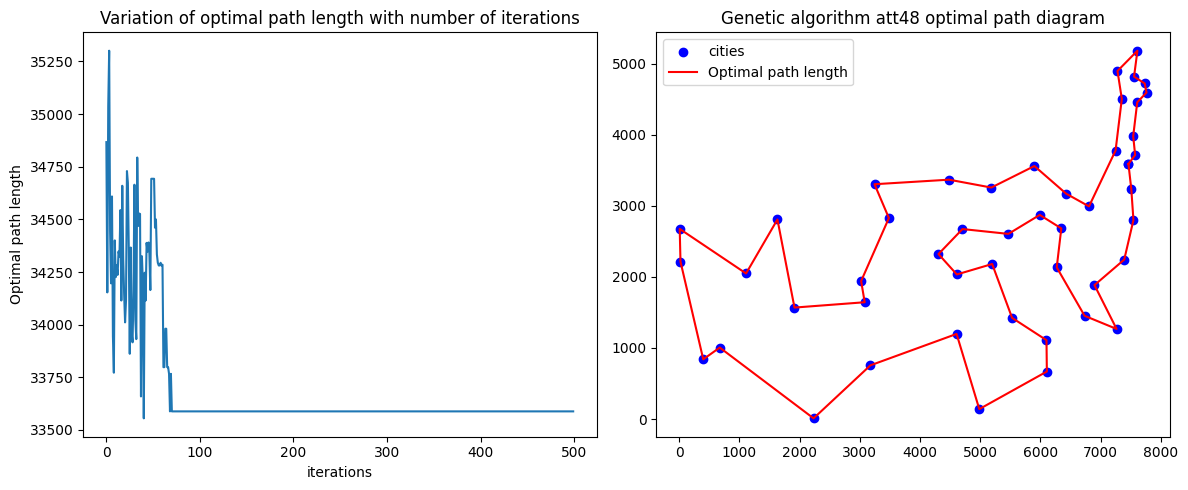

In [11]:
file_path = '/kaggle/input/att48-tsp/att48.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates) 
distance_matrix = calculate_distance_matrix(city_coordinates) 
population_size = 200 
generations = 500 
n_generation_output = 10
best_path, best_length, best_lengths, total_time, earliest_shortest_path_generation = genetic_algorithm_optimized(num_cities, population_size, generations, distance_matrix, n_generation_output)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_generation:{earliest_shortest_path_generation}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Genetic algorithm att48 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

generation:10  best_lengths:702.5197257764044  time:63.90365171432495
generation:20  best_lengths:693.0882553589861  time:127.57034969329834
generation:30  best_lengths:704.5229310181386  time:199.0150375366211
generation:40  best_lengths:701.4541532501196  time:257.41531920433044
generation:50  best_lengths:708.0031599994966  time:319.64628410339355
generation:60  best_lengths:720.2411716600633  time:384.4844434261322
generation:70  best_lengths:686.4240740126473  time:442.0626835823059
generation:80  best_lengths:712.6599003304966  time:505.2497880458832
generation:90  best_lengths:730.1804378709699  time:559.0931553840637
generation:100  best_lengths:704.4303865228953  time:617.5361905097961
generation:110  best_lengths:722.8671330724208  time:672.5613119602203
generation:120  best_lengths:726.8062825610201  time:731.7944414615631
generation:130  best_lengths:707.059709211756  time:795.4700429439545
generation:140  best_lengths:694.7367821593756  time:854.9679136276245
generation:15

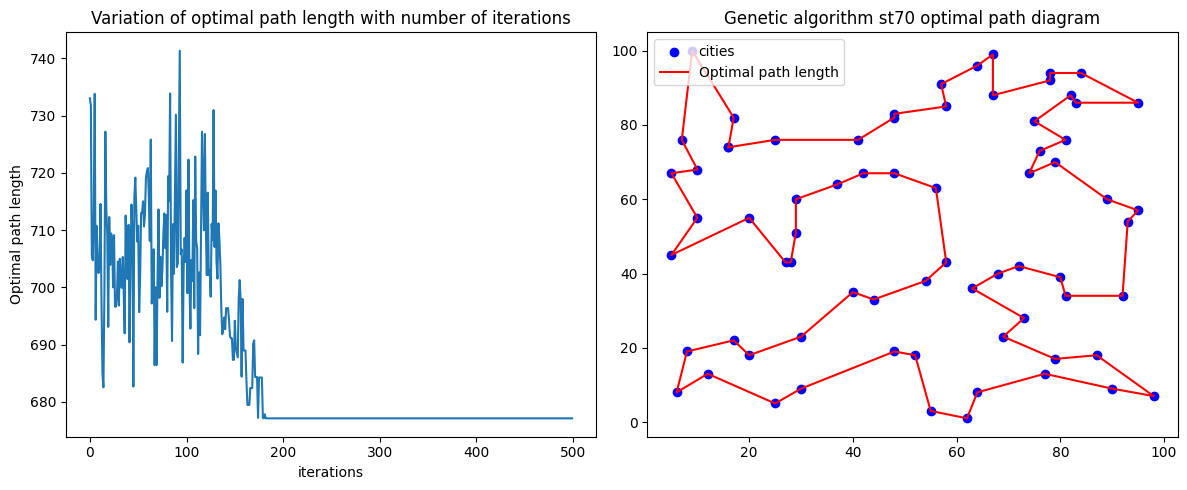

In [2]:
file_path = '/kaggle/input/st70-tsp/st70.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates) 
distance_matrix = calculate_distance_matrix(city_coordinates) 
population_size = 150
generations = 500 
n_generation_output = 10
best_path, best_length, best_lengths, total_time, earliest_shortest_path_generation = genetic_algorithm_optimized(num_cities, population_size, generations, distance_matrix, n_generation_output)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_generation:{earliest_shortest_path_generation}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Genetic algorithm st70 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

generation:10  best_lengths:62086.9592711923  time:260.45305728912354
generation:20  best_lengths:61661.38558155679  time:481.5767970085144
generation:30  best_lengths:61836.9116408456  time:670.9250302314758
generation:40  best_lengths:63994.83828888374  time:758.1651208400726
generation:50  best_lengths:63994.83828888374  time:833.8682818412781
generation:60  best_lengths:63994.83828888374  time:907.1591126918793
generation:70  best_lengths:63994.83828888374  time:977.4110572338104
generation:80  best_lengths:63994.83828888374  time:1056.6944394111633
generation:90  best_lengths:63994.83828888374  time:1134.7222595214844
generation:100  best_lengths:61423.3208118681  time:1211.8631384372711
generation:110  best_lengths:61423.3208118681  time:1297.4449002742767
generation:120  best_lengths:60081.6195549543  time:1389.302047252655
generation:130  best_lengths:60463.07707451399  time:1451.5088682174683
generation:140  best_lengths:60081.6195549543  time:1521.6880433559418
generation:150

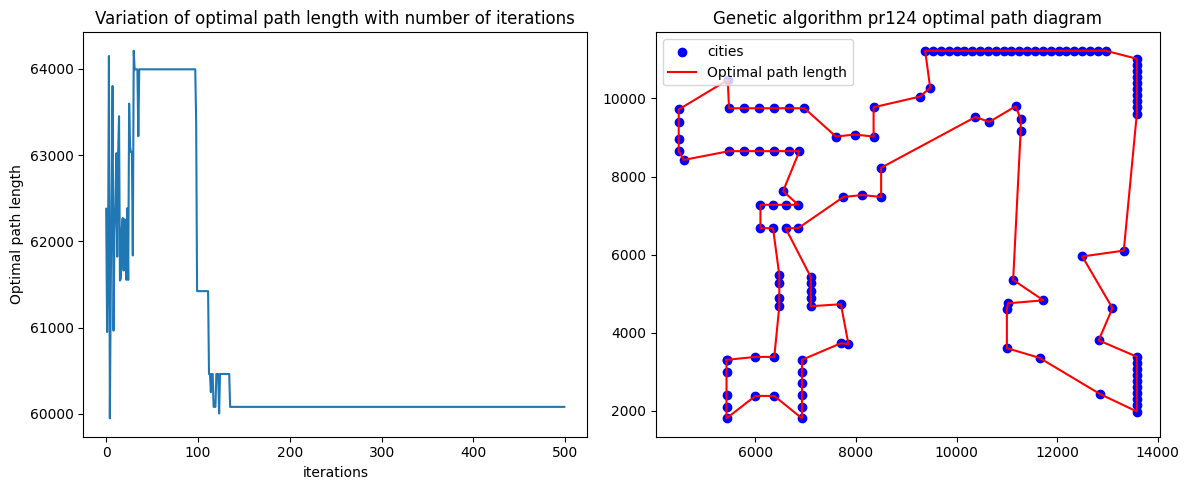

In [3]:
file_path = '/kaggle/input/pr124-tsp/pr124.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates) 
distance_matrix = calculate_distance_matrix(city_coordinates) 
population_size = 100 
generations = 500 
n_generation_output = 10
best_path, best_length, best_lengths, total_time, earliest_shortest_path_generation = genetic_algorithm_optimized(num_cities, population_size, generations, distance_matrix, n_generation_output)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_generation:{earliest_shortest_path_generation}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Genetic algorithm pr124 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

generation:1  best_lengths:97168.49812738351  time:611.8812391757965
generation:2  best_lengths:99059.38233034141  time:1311.5847582817078
generation:3  best_lengths:95804.0015684379  time:1705.5298335552216
generation:4  best_lengths:98186.99458044751  time:2186.6614146232605
generation:5  best_lengths:98186.99458044751  time:2536.197443008423
generation:6  best_lengths:99537.84110764085  time:3015.9867901802063
generation:7  best_lengths:98618.53555039164  time:3321.3995139598846
generation:8  best_lengths:98618.53555039164  time:3757.5017652511597
generation:9  best_lengths:98259.38594852727  time:4281.036446094513
generation:10  best_lengths:98259.38594852727  time:5066.067629098892
generation:11  best_lengths:96989.8577986147  time:5284.255898475647
generation:12  best_lengths:97238.74641733641  time:5982.154709339142
generation:13  best_lengths:98259.38594852727  time:6113.192076683044
generation:14  best_lengths:96651.60587100491  time:6549.419984579086
generation:15  best_lengt

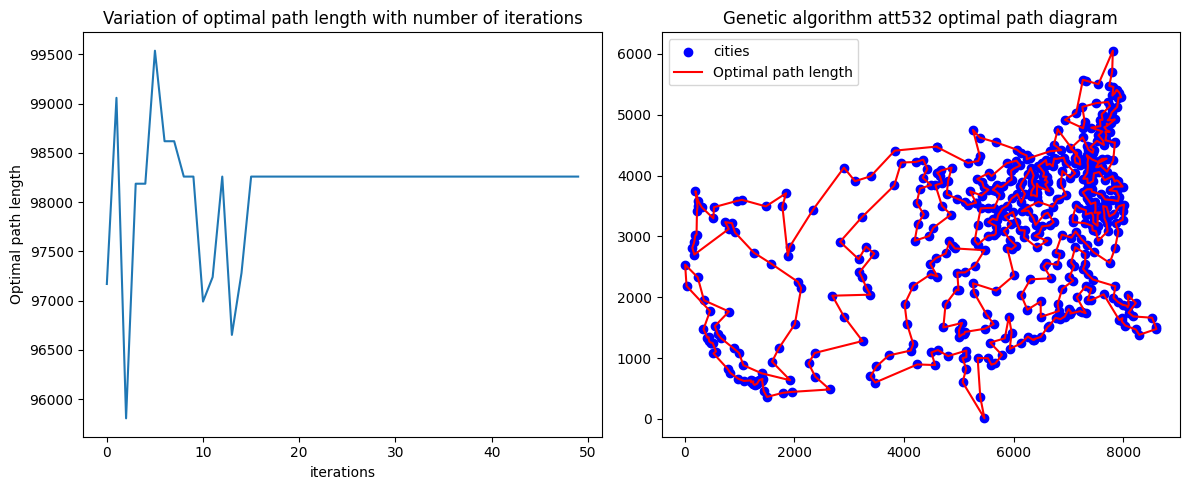

In [2]:
file_path = '/kaggle/input/att532-tsp/att532.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates) 
distance_matrix = calculate_distance_matrix(city_coordinates) 
population_size = 20 
generations = 50
n_generation_output = 1
best_path, best_length, best_lengths, total_time, earliest_shortest_path_generation = genetic_algorithm_optimized(num_cities, population_size, generations, distance_matrix, n_generation_output)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_generation:{earliest_shortest_path_generation}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Genetic algorithm att532 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

蚁群算法

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed

def read_tsp_data(file_path):
    city_coordinates = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        in_node_coord_section = False
        for line in lines:
            line = line.strip()
            if line == 'EOF':
                break
            if line == 'NODE_COORD_SECTION':
                in_node_coord_section = True
                continue
            if in_node_coord_section:
                parts = line.split()
                city_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                city_coordinates[city_id] = (x, y)
    return city_coordinates

def calculate_distance_matrix(city_coordinates):
    num_cities = len(city_coordinates)
    distance_matrix = np.full((num_cities, num_cities), np.inf)
    sorted_cities = sorted(city_coordinates.keys())
    for i in range(num_cities):
        for j in range(num_cities):
            if i == j:
                continue
            city1 = sorted_cities[i]
            city2 = sorted_cities[j]
            x1, y1 = city_coordinates[city1]
            x2, y2 = city_coordinates[city2]
            distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
            distance_matrix[i][j] = distance
    return distance_matrix

def path_length(path, distances):
    length = 0
    num_cities = len(path)
    for i in range(num_cities - 1):
        length += distances[path[i], path[i + 1]]
    length += distances[path[-1], path[0]]
    return length

def two_opt(path, distances):
    improved = True
    while improved:
        improved = False
        for i in range(1, len(path) - 2):
            for j in range(i + 1, len(path)):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                if path_length(new_path, distances) < path_length(path, distances):
                    path = new_path
                    improved = True
    return path

def initialize_pheromone(distances):
    return 1.0 / (distances + 1e-10)

def spread_pheromone(pheromone, all_paths, n_best):
    sorted_paths = sorted(all_paths, key=lambda x: x[1])
    for path, dist in sorted_paths[:n_best]:
        for i in range(len(path) - 1): 
            move = (path[i], path[i + 1])
            pheromone[move] += 1.0 / dist
        move = (path[-1], path[0])
        pheromone[move] += 1.0 / dist 
    return pheromone

def pick_move(pheromone, dist, visited, alpha, beta):
    pheromone = np.copy(pheromone)
    pheromone[list(visited)] = 0
    row = pheromone ** alpha * ((1.0 / (dist + 1e-10)) ** beta)
    norm_row = row / (row.sum() + 1e-10)
    norm_row = norm_row / norm_row.sum()
    move = np_choice(range(len(dist)), 1, p=norm_row)[0]
    return move

def gen_path(start, pheromone, distances, alpha, beta):
    path = [start] 
    visited = set()
    visited.add(start)
    prev = start
    for i in range(len(distances) - 1):
        move = pick_move(pheromone[prev], distances[prev], visited, alpha, beta)
        path.append(move) 
        prev = move
        visited.add(move) 
    path = two_opt(path, distances)
    return path

def gen_all_paths(n_ants, pheromone, distances, alpha, beta):
    paths = Parallel(n_jobs=-1)(delayed(gen_path)(0, pheromone, distances, alpha, beta) for _ in range(n_ants))
    return [(path, path_length(path, distances)) for path in paths]

def ant_colony_optimization(distances, n_ants, n_best, n_iterations, decay, alpha, beta, n_generation_output):
    pheromone = initialize_pheromone(distances)
    all_time_shortest_path = ("placeholder", np.inf)
    best_lengths = []
    start_time = time.time()
    for i in range(n_iterations):
        all_paths = gen_all_paths(n_ants, pheromone, distances, alpha, beta)
        pheromone = spread_pheromone(pheromone, all_paths, n_best)
        shortest_path = min(all_paths, key=lambda x: x[1])
        best_lengths.append(shortest_path[1])
        if shortest_path[1] < all_time_shortest_path[1]:
            all_time_shortest_path = shortest_path
            earliest_shortest_path_iterations = i
        pheromone = np.clip(pheromone * decay, 0.1, 10)
        if (i + 1) % n_generation_output == 0:
            print(f"generation:{i + 1}  best_lengths:{shortest_path[1]}  time:{time.time() - start_time}")
    end_time = time.time()
    return all_time_shortest_path, best_lengths, end_time-start_time, earliest_shortest_path_iterations

def np_choice(a, size, p):
    return np.random.choice(a, size=size, p=p)

generation:10  best_lengths:34350.34095223469  time:21.16243314743042
generation:20  best_lengths:34580.57823002287  time:41.37866187095642
generation:30  best_lengths:34725.223035369665  time:61.83078861236572
generation:40  best_lengths:34550.96937103229  time:82.55416059494019
generation:50  best_lengths:34207.80641627394  time:102.70299506187439
generation:60  best_lengths:35680.788395239484  time:123.63004517555237
generation:70  best_lengths:35303.06142506771  time:144.1996557712555
generation:80  best_lengths:34719.6379557994  time:164.49560737609863
generation:90  best_lengths:34387.928139540374  time:184.90406847000122
generation:100  best_lengths:35280.64578726855  time:205.6384732723236
generation:110  best_lengths:34921.46504409261  time:225.85172367095947
generation:120  best_lengths:34953.05331864924  time:246.37799644470215
generation:130  best_lengths:35300.1890158665  time:266.2691445350647
generation:140  best_lengths:34430.03179232482  time:286.9772095680237
generati

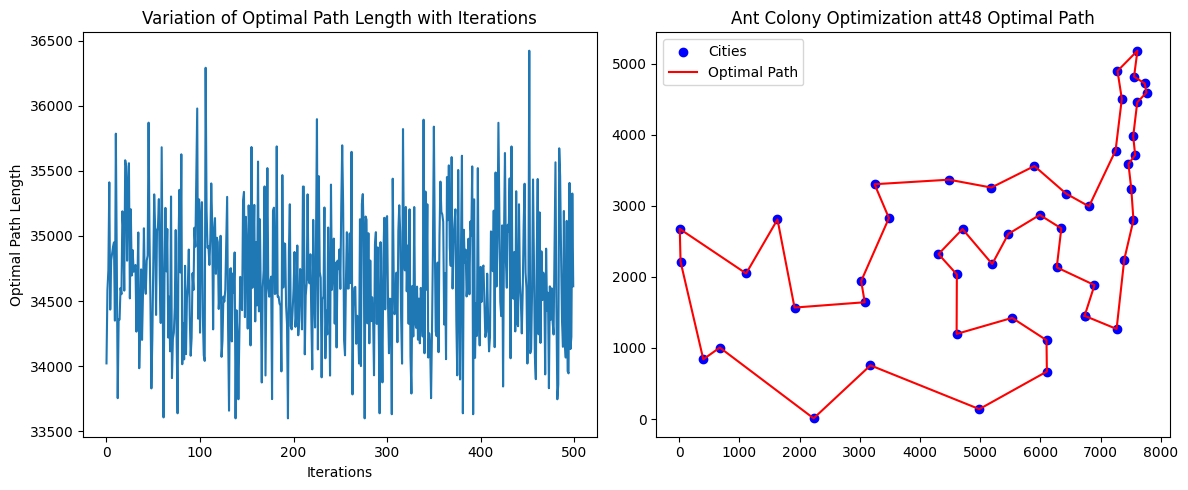

In [5]:
file_path = '/kaggle/input/att48-tsp/att48.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_lengths, total_time, earliest_shortest_path_iterations = ant_colony_optimization(distance_matrix, n_ants=num_cities // 2, n_best=5, n_iterations=500, decay=0.95, alpha=1, beta=2, n_generation_output = 10)
optimal_path = best_path[0]
print(f"optimal_path: {optimal_path}")
print(f"best_path_length: {best_path[1]}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('Iterations')
plt.ylabel('Optimal Path Length')
plt.title('Variation of Optimal Path Length with Iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in optimal_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='Cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal Path')
plt.title('Ant Colony Optimization att48 Optimal Path')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
file_path = '/kaggle/input/st70-tsp/st70.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_lengths, total_time, earliest_shortest_path_iterations = ant_colony_optimization(distance_matrix, n_ants=num_cities // 2, n_best=5, n_iterations=500, decay=0.95, alpha=1, beta=2, n_generation_output = 10)
optimal_path = best_path[0]
print(f"optimal_path: {optimal_path}")
print(f"best_path_length: {best_path[1]}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('Iterations')
plt.ylabel('Optimal Path Length')
plt.title('Variation of Optimal Path Length with Iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in optimal_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='Cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal Path')
plt.title('Ant Colony Optimization st70 Optimal Path')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

generation:1  best_lengths:61032.476230507134  time:48.842506885528564
generation:2  best_lengths:62519.17172699865  time:100.31035423278809
generation:3  best_lengths:62342.37455486252  time:151.22567701339722
generation:4  best_lengths:62596.20034572499  time:199.13148283958435
generation:5  best_lengths:60846.470956815836  time:248.77555966377258
generation:6  best_lengths:61948.08352611687  time:297.59940695762634
generation:7  best_lengths:63484.72523312194  time:349.45868253707886
generation:8  best_lengths:61257.98241264409  time:399.8659324645996
generation:9  best_lengths:61883.21278422303  time:450.4884178638458
generation:10  best_lengths:63347.381929219235  time:501.2358727455139
generation:11  best_lengths:63815.68105542585  time:550.7424712181091
generation:12  best_lengths:60778.93867237052  time:600.2129080295563
generation:13  best_lengths:61392.576820788316  time:651.1452758312225
generation:14  best_lengths:62196.070590925214  time:699.170211315155
generation:15  bes

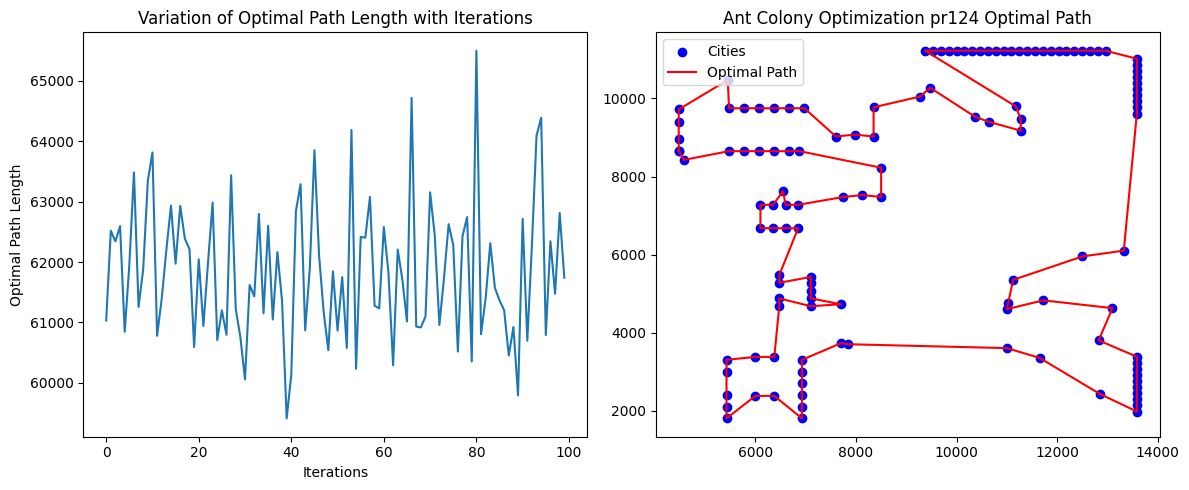

In [4]:
file_path = '/kaggle/input/pr124-tsp/pr124.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_lengths, total_time, earliest_shortest_path_iterations = ant_colony_optimization(distance_matrix, n_ants=30, n_best=5, n_iterations=100, decay=0.95, alpha=1, beta=2, n_generation_output = 1)
optimal_path = best_path[0]
print(f"optimal_path: {optimal_path}")
print(f"best_path_length: {best_path[1]}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('Iterations')
plt.ylabel('Optimal Path Length')
plt.title('Variation of Optimal Path Length with Iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in optimal_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='Cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal Path')
plt.title('Ant Colony Optimization pr124 Optimal Path')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
file_path = '/kaggle/input/att532-tsp/att532.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_lengths, total_time, earliest_shortest_path_iterations = ant_colony_optimization(distance_matrix, n_ants=30, n_best=5, n_iterations=50, decay=0.95, alpha=1, beta=2, n_generation_output=1)
optimal_path = best_path[0]
print(f"optimal_path: {optimal_path}")
print(f"best_path_length: {best_path[1]}")
print(f"total_time: {total_time:.2f} 秒")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('Iterations')
plt.ylabel('Optimal Path Length')
plt.title('Variation of Optimal Path Length with Iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in optimal_path])
path_coords = np.vstack([path_coords, path_coords[0]])
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='Cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal Path')
plt.title('Ant Colony Optimization att532 Optimal Path')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

pso粒子群算法

In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time
from collections import Counter

def read_tsp_data(file_path):
    city_coordinates = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        in_node_coord_section = False
        for line in lines:
            line = line.strip()
            if line == 'EOF':
                break
            if line == 'NODE_COORD_SECTION':
                in_node_coord_section = True
                continue
            if in_node_coord_section:
                parts = line.split()
                city_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                city_coordinates[city_id] = (x, y)
    return city_coordinates

def calculate_distance_matrix(city_coordinates):
    num_cities = len(city_coordinates)
    distance_matrix = np.full((num_cities, num_cities), np.inf)
    sorted_cities = sorted(city_coordinates.keys())
    for i in range(num_cities):
        for j in range(num_cities):
            if i == j:
                continue
            city1 = sorted_cities[i]
            city2 = sorted_cities[j]
            x1, y1 = city_coordinates[city1]
            x2, y2 = city_coordinates[city2]
            distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
            distance_matrix[i][j] = distance
    return distance_matrix

def path_length(path, distances):
    length = 0
    num_cities = len(path)
    for i in range(num_cities - 1):
        length += distances[path[i], path[i + 1]]
    length += distances[path[-1], path[0]]
    return length

def initialize_particles(num_particles, num_cities):
    particles = []
    for _ in range(num_particles):
        path = list(range(num_cities))
        random.shuffle(path)
        particles.append(path)
    return particles

def swap(path, i, j):
    new_path = path.copy()
    new_path[i], new_path[j] = new_path[j], new_path[i]
    return new_path

def two_opt(path, distances):
    improved = True
    while improved:
        improved = False
        for i in range(1, len(path) - 2):
            for j in range(i + 1, len(path)):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                if len(new_path) == len(set(new_path)) and path_length(new_path, distances) < path_length(path, distances):
                    path = new_path
                    improved = True
    return path

def update_velocity(particle, pbest, gbest, w):
    new_velocity = particle.copy()
    for i in range(len(particle)):
        if random.random() < w:
            continue
        elif random.random() < 0.5:
            new_velocity[i] = pbest[i]
        else:
            new_velocity[i] = gbest[i]
    return new_velocity

def update_position(particle, velocity):
    new_particle = particle.copy()
    for i in range(len(particle)):
        if random.random() < 0.5:
            new_particle[i] = velocity[i]
    if len(new_particle) != len(set(new_particle)):
        missing_cities = set(range(len(particle))) - set(new_particle)
        duplicate_cities = [item for item, count in Counter(new_particle).items() if count > 1]
        for city in duplicate_cities:
            index = new_particle.index(city, new_particle.index(city) + 1)
            new_particle[index] = missing_cities.pop()
    return new_particle

def pso_tsp(city_coordinates, distance_matrix, num_particles, max_iter, n_generation_output):
    num_cities = len(city_coordinates)
    particles = initialize_particles(num_particles, num_cities)
    velocities = [random.sample(range(num_cities), num_cities) for _ in range(num_particles)]
    pbest = particles.copy()
    pbest_lengths = [path_length(p, distance_matrix) for p in particles]
    gbest = pbest[np.argmin(pbest_lengths)]
    gbest_length = min(pbest_lengths)
    best_lengths = []
    start_time = time.time()
    for iteration in range(max_iter):
        w = 0.9 - (0.9 - 0.4) * (iteration / max_iter)
        for i in range(num_particles):
            velocities[i] = update_velocity(particles[i], pbest[i], gbest, w)
            particles[i] = update_position(particles[i], velocities[i])
            particles[i] = two_opt(particles[i], distance_matrix)
            current_length = path_length(particles[i], distance_matrix)
            if current_length < pbest_lengths[i]:
                pbest[i] = particles[i]
                pbest_lengths[i] = current_length
                if current_length < gbest_length:
                    gbest = particles[i]
                    gbest_length = current_length
                    earliest_shortest_path_iterations = iteration
        if iteration % 10 == 0:
            for i in range(int(num_particles * 0.1)):
                particles[i] = list(range(num_cities))
                random.shuffle(particles[i])
        best_lengths.append(gbest_length)
        if (iteration + 1) % n_generation_output == 0:
            current_time = time.time() - start_time
            print(f"generation:{iteration + 1}  best_lengths:{gbest_length}  time:{current_time}")
    end_time = time.time()
    return gbest, gbest_length, best_lengths, end_time-start_time, earliest_shortest_path_iterations

generation:10  best_lengths:34235.653990193416  time:26.608015060424805
generation:20  best_lengths:34235.653990193416  time:51.40188479423523
generation:30  best_lengths:34235.653990193416  time:80.21223616600037
generation:40  best_lengths:33930.52083120852  time:109.81592774391174
generation:50  best_lengths:33930.52083120852  time:139.12359189987183
generation:60  best_lengths:33930.52083120852  time:169.63906979560852
generation:70  best_lengths:33659.380722890186  time:200.1135015487671
generation:80  best_lengths:33639.25024795531  time:233.76581001281738
generation:90  best_lengths:33639.25024795531  time:265.91518998146057
generation:100  best_lengths:33639.25024795531  time:296.98025488853455
generation:110  best_lengths:33639.25024795531  time:327.4604640007019
generation:120  best_lengths:33639.25024795531  time:357.7233021259308
generation:130  best_lengths:33639.25024795531  time:387.65905594825745
generation:140  best_lengths:33600.56145847071  time:419.0678765773773
gen

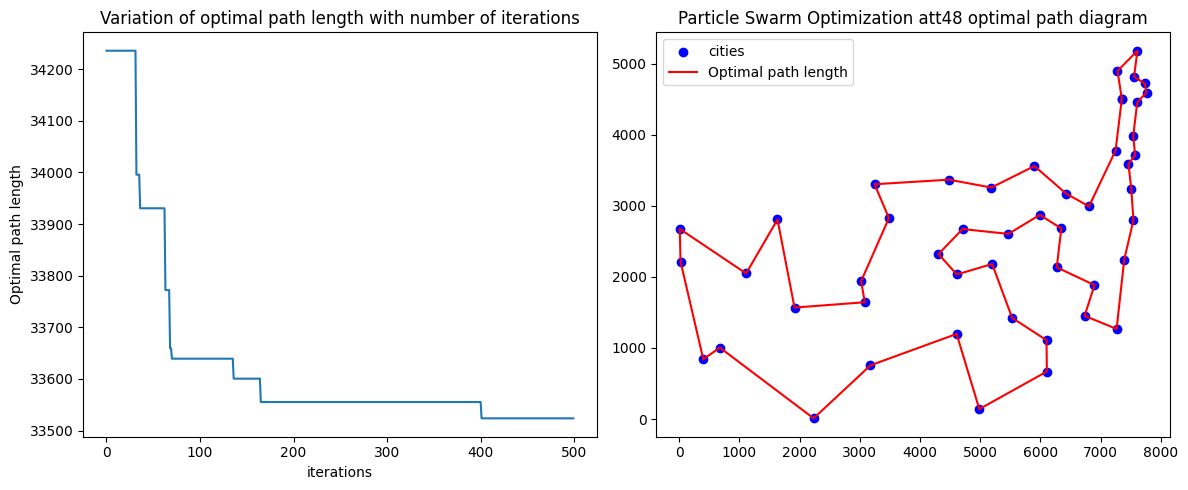

In [18]:
file_path = '/kaggle/input/att48-tsp/att48.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_length, best_lengths, total_time, earliest_shortest_path_iterations = pso_tsp(city_coordinates, distance_matrix, num_particles=30, max_iter=500, n_generation_output=10)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time:{total_time}")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])  # 回到起始点
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Particle Swarm Optimization att48 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

generation:10  best_lengths:699.4768129769116  time:101.67184281349182
generation:20  best_lengths:687.299893400794  time:197.23146057128906
generation:30  best_lengths:682.5431615341813  time:300.2441244125366
generation:40  best_lengths:682.5431615341813  time:411.7047288417816
generation:50  best_lengths:682.5431615341813  time:517.9733150005341
generation:60  best_lengths:682.5431615341813  time:625.3796300888062
generation:70  best_lengths:682.5431615341813  time:736.9917187690735
generation:80  best_lengths:682.5431615341813  time:846.9094276428223
generation:90  best_lengths:682.5431615341813  time:951.9204170703888
generation:100  best_lengths:678.6207964799778  time:1059.8279676437378
generation:110  best_lengths:678.6207964799778  time:1160.9943253993988
generation:120  best_lengths:678.6207964799778  time:1259.134333372116
generation:130  best_lengths:678.6207964799778  time:1356.8805067539215
generation:140  best_lengths:678.6207964799778  time:1452.690853357315
generation:

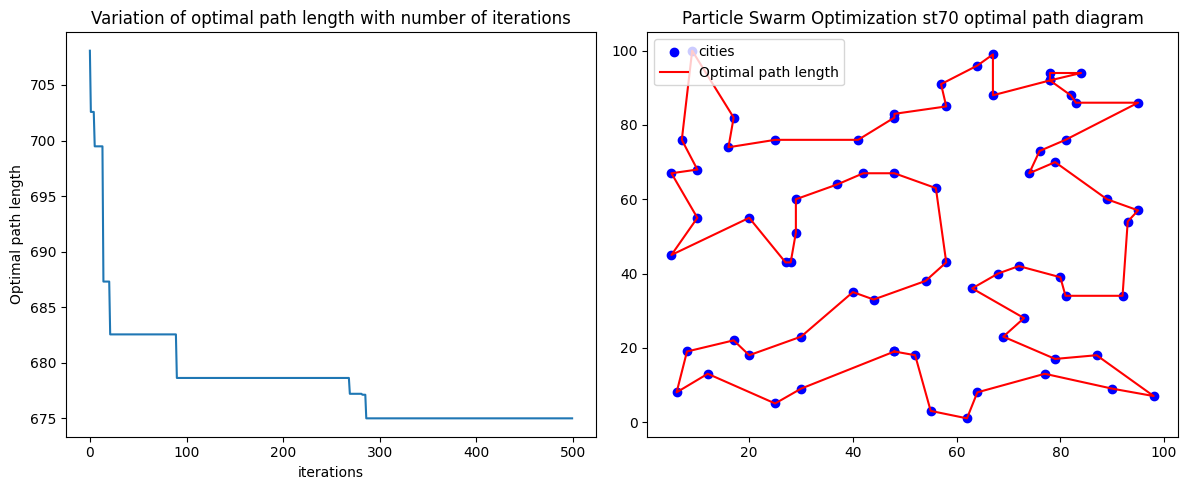

In [16]:
file_path = '/kaggle/input/st70-tsp/st70.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_length, best_lengths, total_time, earliest_shortest_path_iterations = pso_tsp(city_coordinates, distance_matrix, num_particles=30, max_iter=500, n_generation_output=10)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time:{total_time}")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])  # 回到起始点
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Particle Swarm Optimization st70 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
file_path = '/kaggle/input/pr124-tsp/pr124.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_length, best_lengths, total_time, earliest_shortest_path_iterations = pso_tsp(city_coordinates, distance_matrix, num_particles=30, max_iter=200, n_generation_output=10)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time:{total_time}")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])  # 回到起始点
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Particle Swarm Optimization pr124 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
file_path = '/kaggle/input/att532-tsp/att532.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_path, best_length, best_lengths, total_time, earliest_shortest_path_iterations = pso_tsp(city_coordinates, distance_matrix, num_particles=5, max_iter=20, n_generation_output=1)
print(f"best_path: {best_path}")
print(f"best_length: {best_length}")
print(f"total_time:{total_time}")
print(f"earliest_shortest_path_iterations:{earliest_shortest_path_iterations}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])  # 回到起始点
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Particle Swarm Optimization att532 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

generation:1  best_lengths:93976.3818590168  time:1582.7631795406342
generation:2  best_lengths:93976.3818590168  time:2961.045780658722


KeyboardInterrupt: 

*GA*

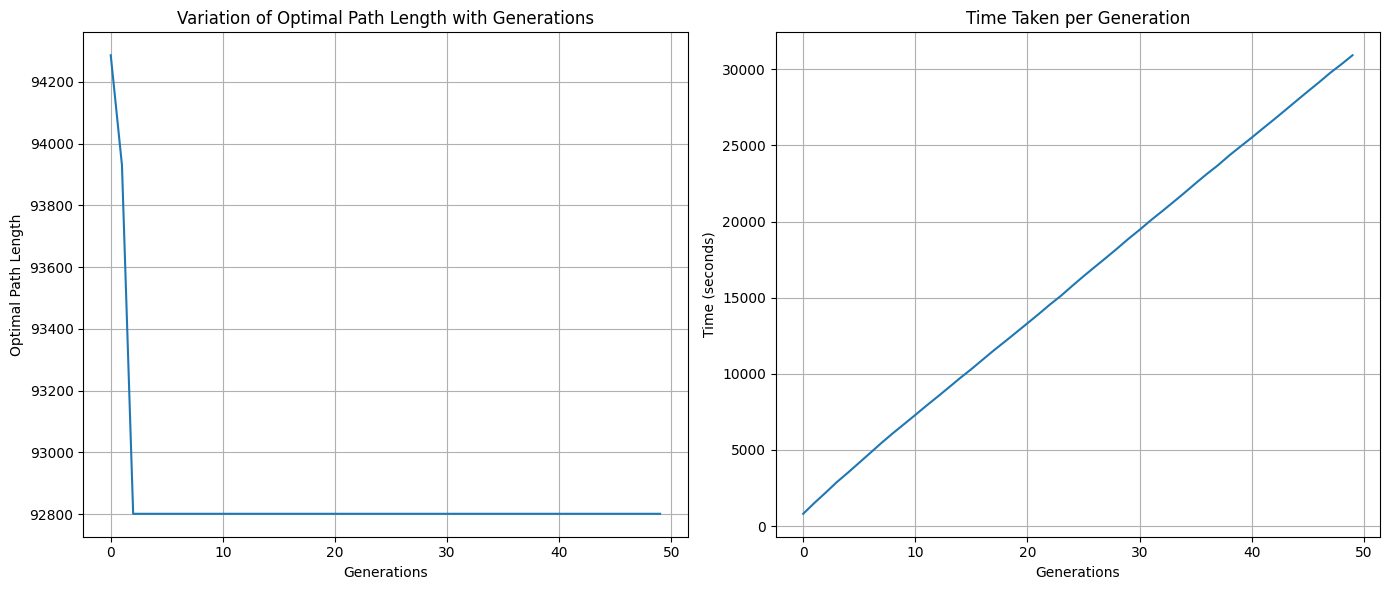

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data provided
generations = list(range(0, 50))
best_lengths = [94286.3, 93930.5, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9]

times = [807.227, 1519.63, 2193.58, 2888.17, 3513.76, 4164.26, 4816.58, 5473.21, 6098.24, 6696.59,
         7299.52, 7912.1, 8505.08, 9110.53, 9724.31, 10307.7, 10924.3, 11538.8, 12122.3, 12717.8,
         13318.2, 13922.1, 14544.8, 15129.6, 15775, 16405.6, 17012.5, 17613.2, 18227.3, 18860.1,
         19453.6, 20079.5, 20667.2, 21270.7, 21882.3, 22511.4, 23123.5, 23700.4, 24338.6, 24929.4,
         25508.7, 26113, 26707.4, 27316.6, 27932.5, 28541.4, 29139.9, 29761.6, 30327.9, 30922.7]

# Plotting
plt.figure(figsize=(14, 6))

# Plot 1: Variation of optimal path length with number of iterations
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('Generations')
plt.ylabel('Optimal Path Length')
plt.title('Variation of Optimal Path Length with Generations')
plt.grid(True)

# Plot 2: Time taken per generation
plt.subplot(1, 2, 2)
plt.plot(generations, times)
plt.xlabel('Generations')
plt.ylabel('Time (seconds)')
plt.title('Time Taken per Generation')
plt.grid(True)

plt.tight_layout()
plt.show()

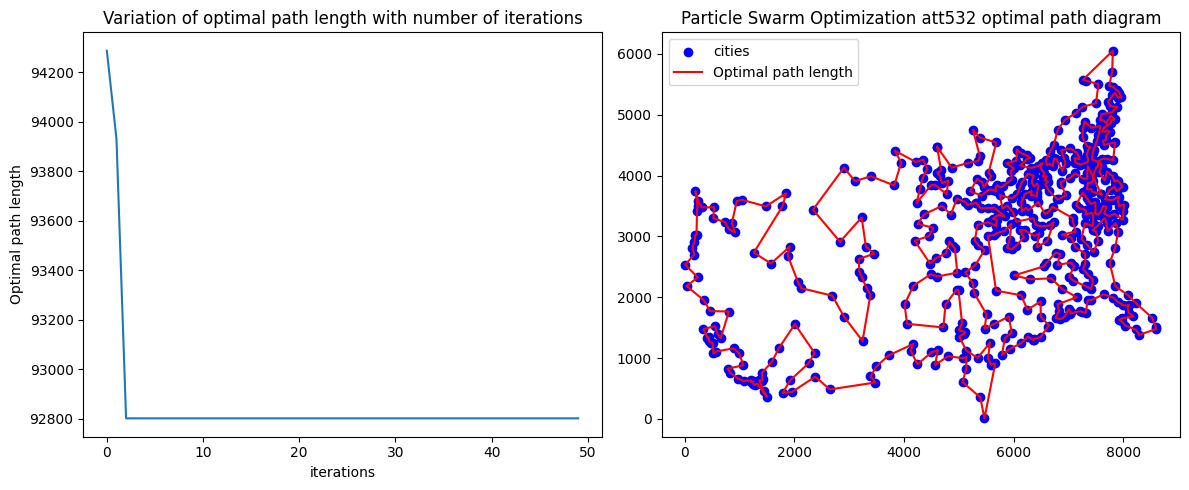

92800.91923408613


In [9]:
file_path = '/kaggle/input/att532-tsp/att532.tsp'
city_coordinates = read_tsp_data(file_path)
num_cities = len(city_coordinates)
distance_matrix = calculate_distance_matrix(city_coordinates)
best_lengths = [94286.3, 93930.5, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9,
                92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9, 92800.9]
best_path = [202,195,184,185,163,162,154,132,114,113,103,99,93,86,70,64,53,47,42,35,37,30,38,48,59,62,65,73,82,95,105,96,78,84,71,63,67,76,98,123,83,79,110,104,106,88,69,57,39,26,20,18,15,4,3,2,0,1,5,6,8,7,9,12,13,10,11,14,16,17,19,21,27,25,32,29,23,22,24,28,31,33,34,36,43,45,41,44,46,50,51,52,58,56,54,89,80,81,92,107,112,125,147,124,137,157,148,152,177,190,179,188,215,217,209,220,236,230,254,279,263,271,262,241,235,258,268,261,251,224,229,218,210,196,232,246,252,266,259,270,286,297,288,322,332,345,324,306,303,296,275,287,305,290,309,341,357,386,398,408,433,447,450,459,452,443,438,437,435,428,424,415,412,414,413,407,402,396,403,404,425,422,419,426,423,416,429,436,434,418,409,401,391,378,379,373,366,358,347,351,363,356,365,375,381,387,390,380,372,367,361,350,337,321,314,308,282,274,240,260,264,223,253,245,256,225,199,189,206,204,208,197,175,166,178,165,155,134,133,161,176,200,211,203,249,233,257,281,276,293,299,295,285,327,338,311,318,304,302,320,333,343,339,323,291,307,312,315,317,394,399,417,406,432,444,446,462,467,468,469,460,476,480,489,466,455,430,441,449,427,395,383,369,364,344,331,325,294,283,298,280,278,269,272,244,247,248,227,226,231,222,212,267,234,265,292,300,319,326,359,354,348,328,334,342,370,374,371,384,410,440,448,411,392,393,439,453,454,457,458,461,483,493,473,494,500,497,531,530,518,504,492,495,491,501,481,485,499,482,477,490,503,508,521,525,509,527,528,513,498,486,442,478,496,507,511,515,512,526,529,522,524,523,520,517,519,514,516,510,506,505,502,487,479,484,488,475,474,472,471,463,464,451,445,456,465,421,420,405,385,377,362,352,340,330,316,313,255,239,191,221,243,242,277,284,301,310,289,219,216,238,198,237,346,360,336,353,382,389,400,431,470,397,388,376,368,355,349,335,273,329,250,116,156,138,172,97,68,94,87,120,141,183,228,170,171,201,151,164,136,127,126,121,61,60,115,100,91,75,40,49,55,130,135,181,158,145,194,207,186,187,193,182,169,174,180,173,153,146,122,119,102,90,66,72,74,77,85,108,118,109,101,117,128,140,139,149,150,160,167,192,214,213,205,168,159,142,131,144,143,129,111]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_lengths)
plt.xlabel('iterations')
plt.ylabel('Optimal path length')
plt.title('Variation of optimal path length with number of iterations')
sorted_cities = sorted(city_coordinates.keys())
path_coords = np.array([city_coordinates[sorted_cities[i]] for i in best_path])
path_coords = np.vstack([path_coords, path_coords[0]])  # 回到起始点
plt.subplot(1, 2, 2)
plt.scatter(path_coords[:, 0], path_coords[:, 1], color='blue', label='cities')
plt.plot(path_coords[:, 0], path_coords[:, 1], 'r-', label='Optimal path length')
plt.title('Particle Swarm Optimization att532 optimal path diagram')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
length = 0
num_cities = len(best_path)
distances = distance_matrix
for i in range(num_cities - 1):
    length += distances[best_path[i], best_path[i + 1]]
length += distances[best_path[-1], best_path[0]]
print(length)